# Auditing the Met Office assets on the Planetary Computer

In [1]:
from __future__ import annotations
from dataclasses import dataclass


@dataclass(frozen=True)
class MetOfficePath:
    interval: str
    variable: str

    @classmethod
    def parse(cls, path: str) -> MetOfficePath:
        file_name = path.split("/")[-1]
        parts = file_name.split("-")
        return MetOfficePath(interval=parts[1], variable=parts[2].split(".")[0])

## Microsoft

In [2]:
import httpx
from obstore.store import AzureStore

sas_key = httpx.get(
    "https://planetarycomputer.microsoft.com/api/sas/v1/token/ukmoeuwest/deterministic"
).json()["token"]
store = AzureStore(
    account_name="ukmoeuwest",
    container_name="deterministic",
    sas_key=sas_key,
    prefix="global",
)

In [3]:
from collections import defaultdict


@dataclass(frozen=True)
class MicrosoftPrefix:
    collection: str
    year: int
    month: int

    def to_str(self) -> str:
        return f"{self.collection}/{self.year}{self.month:02d}01T0000Z"


prefixes: list[MicrosoftPrefix] = []
for year in [2024, 2025, 2026]:
    for month in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:
        if year == 2026 and month > 3:
            continue
        for collection in ["near-surface", "pressure", "height", "whole-atmosphere"]:
            prefixes.append(
                MicrosoftPrefix(collection=collection, year=year, month=month)
            )


print(prefixes)

[MicrosoftPrefix(collection='near-surface', year=2024, month=1), MicrosoftPrefix(collection='pressure', year=2024, month=1), MicrosoftPrefix(collection='height', year=2024, month=1), MicrosoftPrefix(collection='whole-atmosphere', year=2024, month=1), MicrosoftPrefix(collection='near-surface', year=2024, month=2), MicrosoftPrefix(collection='pressure', year=2024, month=2), MicrosoftPrefix(collection='height', year=2024, month=2), MicrosoftPrefix(collection='whole-atmosphere', year=2024, month=2), MicrosoftPrefix(collection='near-surface', year=2024, month=3), MicrosoftPrefix(collection='pressure', year=2024, month=3), MicrosoftPrefix(collection='height', year=2024, month=3), MicrosoftPrefix(collection='whole-atmosphere', year=2024, month=3), MicrosoftPrefix(collection='near-surface', year=2024, month=4), MicrosoftPrefix(collection='pressure', year=2024, month=4), MicrosoftPrefix(collection='height', year=2024, month=4), MicrosoftPrefix(collection='whole-atmosphere', year=2024, month=4),

In [4]:
from asyncio import TaskGroup

counts: defaultdict[tuple[MicrosoftPrefix, str], int] = defaultdict(int)


async def count_prefix(
    prefix: MicrosoftPrefix,
) -> dict[tuple[MicrosoftPrefix, str], int]:
    result: dict[tuple[MicrosoftPrefix, str], int] = defaultdict(int)
    async for list_result in store.list(prefix=prefix.to_str()):
        for object_meta in list_result:
            if object_meta["path"].endswith(".updated"):
                continue
            path = MetOfficePath.parse(object_meta["path"])
            result[(prefix, path.interval)] += 1
    return result


async with TaskGroup() as task_group:
    tasks = {
        task_group.create_task(count_prefix(prefix)): prefix for prefix in prefixes
    }

for task in tasks:
    for key, value in task.result().items():
        counts[key] += value

print(counts)

defaultdict(<class 'int'>, {(MicrosoftPrefix(collection='near-surface', year=2024, month=1), 'PT0000H00M'): 18, (MicrosoftPrefix(collection='near-surface', year=2024, month=1), 'PT0001H00M'): 26, (MicrosoftPrefix(collection='near-surface', year=2024, month=1), 'PT0002H00M'): 27, (MicrosoftPrefix(collection='near-surface', year=2024, month=1), 'PT0003H00M'): 28, (MicrosoftPrefix(collection='near-surface', year=2024, month=1), 'PT0004H00M'): 27, (MicrosoftPrefix(collection='near-surface', year=2024, month=1), 'PT0005H00M'): 27, (MicrosoftPrefix(collection='near-surface', year=2024, month=1), 'PT0006H00M'): 25, (MicrosoftPrefix(collection='near-surface', year=2024, month=1), 'PT0007H00M'): 27, (MicrosoftPrefix(collection='near-surface', year=2024, month=1), 'PT0008H00M'): 25, (MicrosoftPrefix(collection='near-surface', year=2024, month=1), 'PT0009H00M'): 26, (MicrosoftPrefix(collection='near-surface', year=2024, month=1), 'PT0010H00M'): 23, (MicrosoftPrefix(collection='near-surface', year

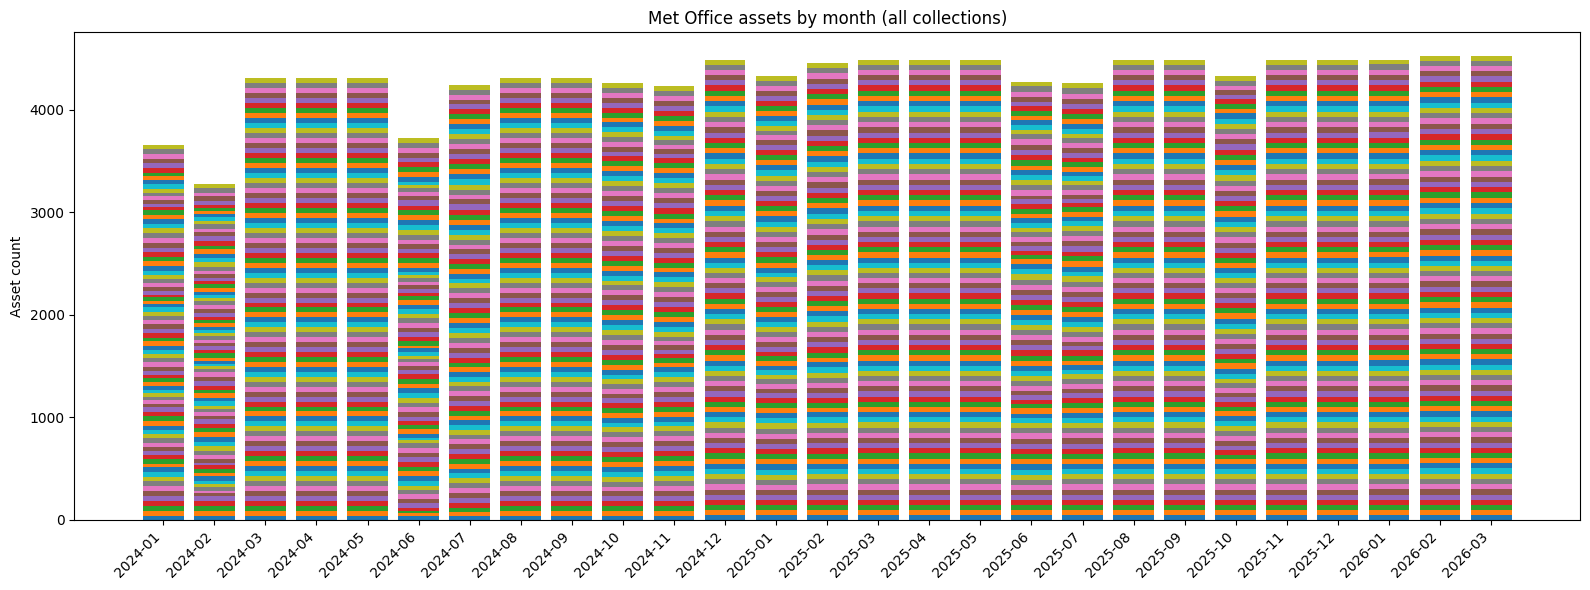

In [ ]:
import numpy
from matplotlib import pyplot

intervals = sorted({interval for _, interval in counts})
year_months = sorted({(p.year, p.month) for p in prefixes})
labels = [f"{y}-{m:02d}" for y, m in year_months]
x = numpy.arange(len(year_months))
bottom = numpy.zeros(len(year_months))

figure, axis = pyplot.subplots(figsize=(16, 6))

for interval in intervals:
    values = numpy.array(
        [
            sum(
                counts.get((p, interval), 0)
                for p in prefixes
                if (p.year, p.month) == ym
            )
            for ym in year_months
        ]
    )
    axis.bar(x, values, bottom=bottom, label=interval)
    bottom += values

axis.set_xticks(x)
axis.set_xticklabels(labels, rotation=45, ha="right")
axis.set_ylabel("Asset count")
axis.set_title("Met Office assets by month (all collections)")
pyplot.tight_layout()

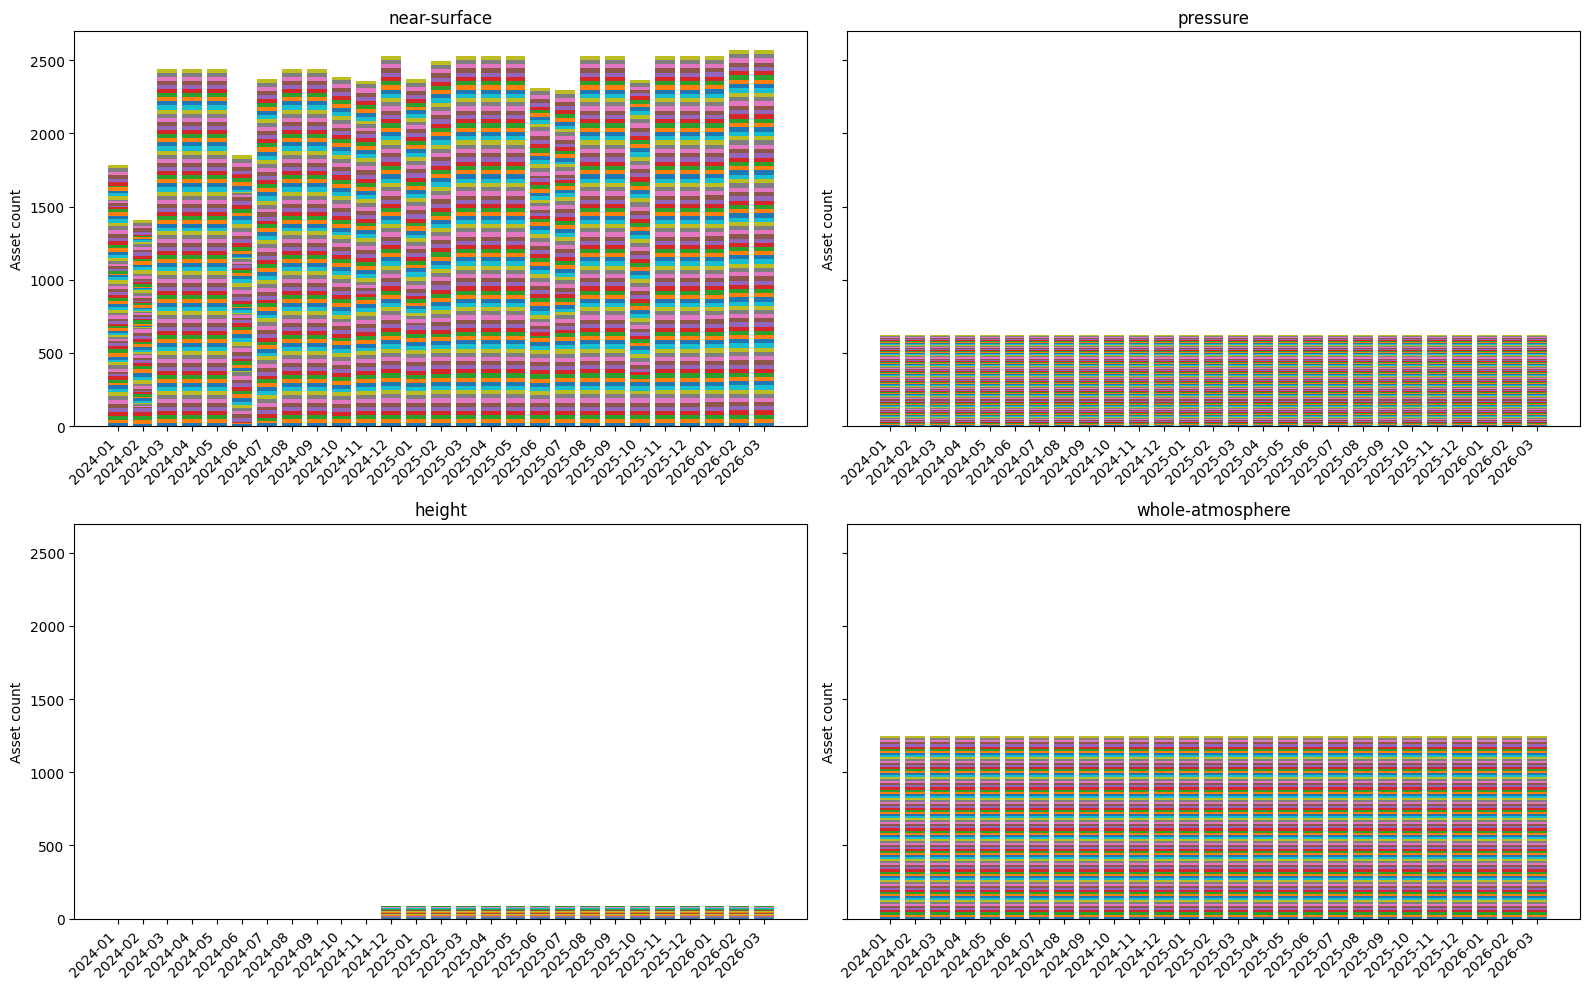

In [ ]:
collections = ["near-surface", "pressure", "height", "whole-atmosphere"]
figure, axes = pyplot.subplots(2, 2, figsize=(16, 10), sharey=True)

for ax, collection in zip(axes.flat, collections):
    bottom = numpy.zeros(len(year_months))
    for interval in intervals:
        values = numpy.array(
            [
                sum(
                    counts.get((p, interval), 0)
                    for p in prefixes
                    if (p.year, p.month) == ym and p.collection == collection
                )
                for ym in year_months
            ]
        )
        ax.bar(x, values, bottom=bottom, label=interval)
        bottom += values
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Asset count")
    ax.set_title(collection)

pyplot.tight_layout()

## AWS

We need to get the variables that are considered "near-surface".

In [9]:
from obstore.store import S3Store

store = S3Store(
    bucket="met-office-atmospheric-model-data",
    region="eu-west-2",
    skip_signature=True,
    prefix="global-deterministic-10km",
)

@dataclass(frozen=True)
class AwsPrefix:
    year: int
    month: int

    def to_str(self) -> str:
        return f"{self.year}{self.month:02d}01T0000Z"

prefixes = []
for year in [2024, 2025, 2026]:
    for month in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:
        if year == 2026 and month > 3:
            continue
        prefixes.append(AwsPrefix(year=year, month=month))

In [11]:
from stactools.met_office_deterministic.constants import Theme

counts: defaultdict[tuple[AwsPrefix, str], int] = defaultdict(int)


async def count_prefix(
    prefix: AwsPrefix,
) -> dict[tuple[AwsPrefix, str], int]:
    result: dict[tuple[AwsPrefix, str], int] = defaultdict(int)
    async for list_result in store.list(prefix=prefix.to_str()):
        for object_meta in list_result:
            if object_meta["path"].endswith(".updated"):
                continue
            path = MetOfficePath.parse(object_meta["path"])
            try:
                if Theme.from_parameter(path.variable) == Theme.near_surface:
                    result[(prefix, path.interval)] += 1
            except ValueError:
                pass
    return result


async with TaskGroup() as task_group:
    tasks = {
        task_group.create_task(count_prefix(prefix)): prefix for prefix in prefixes
    }

for task in tasks:
    for key, value in task.result().items():
        counts[key] += value

print(counts)


defaultdict(<class 'int'>, {(AwsPrefix(year=2024, month=3), 'PT0000H00M'): 19, (AwsPrefix(year=2024, month=3), 'PT0001H00M'): 18, (AwsPrefix(year=2024, month=3), 'PT0002H00M'): 18, (AwsPrefix(year=2024, month=3), 'PT0003H00M'): 19, (AwsPrefix(year=2024, month=3), 'PT0004H00M'): 18, (AwsPrefix(year=2024, month=3), 'PT0005H00M'): 18, (AwsPrefix(year=2024, month=3), 'PT0006H00M'): 19, (AwsPrefix(year=2024, month=3), 'PT0007H00M'): 18, (AwsPrefix(year=2024, month=3), 'PT0008H00M'): 18, (AwsPrefix(year=2024, month=3), 'PT0009H00M'): 19, (AwsPrefix(year=2024, month=3), 'PT0010H00M'): 18, (AwsPrefix(year=2024, month=3), 'PT0011H00M'): 18, (AwsPrefix(year=2024, month=3), 'PT0012H00M'): 19, (AwsPrefix(year=2024, month=3), 'PT0013H00M'): 18, (AwsPrefix(year=2024, month=3), 'PT0014H00M'): 18, (AwsPrefix(year=2024, month=3), 'PT0015H00M'): 19, (AwsPrefix(year=2024, month=3), 'PT0016H00M'): 18, (AwsPrefix(year=2024, month=3), 'PT0017H00M'): 18, (AwsPrefix(year=2024, month=3), 'PT0018H00M'): 19, (Aw

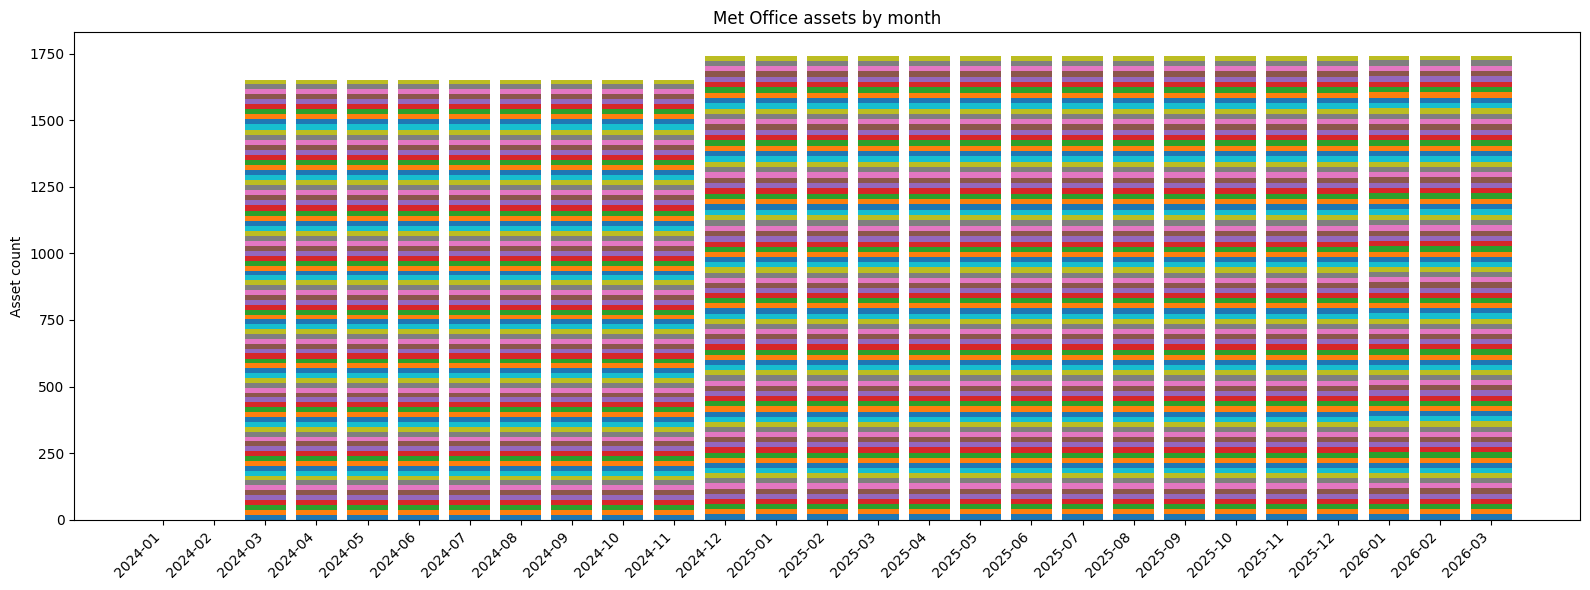

In [12]:
intervals = sorted({interval for _, interval in counts})
year_months = sorted({(p.year, p.month) for p in prefixes})
labels = [f"{y}-{m:02d}" for y, m in year_months]
x = numpy.arange(len(year_months))
bottom = numpy.zeros(len(year_months))

figure, axis = pyplot.subplots(figsize=(16, 6))

for interval in intervals:
    values = numpy.array(
        [
            sum(
                counts.get((p, interval), 0)
                for p in prefixes
                if (p.year, p.month) == ym
            )
            for ym in year_months
        ]
    )
    axis.bar(x, values, bottom=bottom, label=interval)
    bottom += values

axis.set_xticks(x)
axis.set_xticklabels(labels, rotation=45, ha="right")
axis.set_ylabel("Asset count")
axis.set_title("Met Office assets by month")
pyplot.tight_layout()
